<a href="https://colab.research.google.com/github/musowjanya/Machine-Learning/blob/main/Pytorch_gradientDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Sample data
x = np.array([1, 2, 3, 4, 5])
y =np.array([3.5, 5.5, 6.5, 9.5, 10.5])

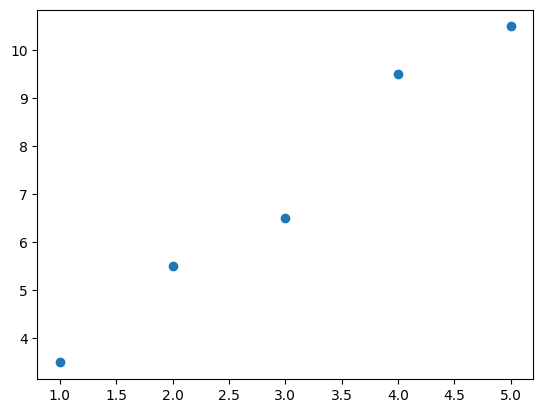

In [3]:
plt.scatter(x, y)
plt.show()

In [4]:
# Initialize parameters
w = 0.0
b = 0.0
learning_rate = 0.01
epochs=100

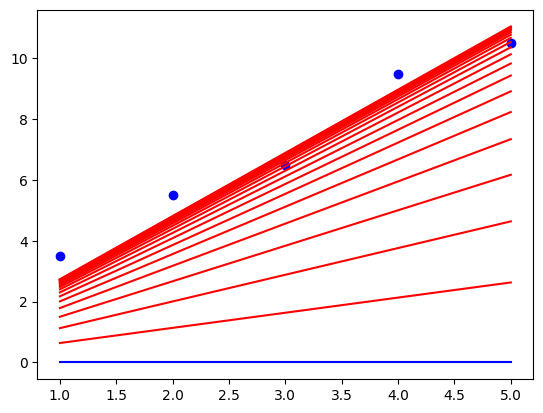

In [5]:
losses=[]
plt.scatter(x, y, color='blue')
plt.plot(x, w * x + b, color='blue')
# Gradient Descent Loop
for epoch in range(20):
    y_pred = w * x + b
    # loss = np.mean((y_pred - y) ** 2)

    dw = np.mean(2 * x * (y_pred - y))
    db = np.mean(2 * (y_pred - y))

    w = w - 0.01 * dw
    b = b - 0.01 * db

    plt.plot(x, w * x + b, color='red')

With Pytorch gradient Descent

In [6]:
import torch

In [7]:
# x = torch.tensor([5.0], dtype=torch.float32, requires_grad=True)

In [8]:
#x

In [9]:
# y = torch.log(x**2)

In [10]:
# y.backward() # => dy/dx + dy/dz + dy/k + ...

In [11]:
# x.grad # => dy/dx

In [12]:
torch.randn(5)

tensor([ 0.3901,  0.7068,  1.5374,  0.7463, -0.2180])

In [13]:
# Data- convert to float tensors
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# Initialize weights (requires_grad=True to track gradients)
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

Epoch 0: Loss = 90.3102, w = 0.3090, b = -0.7814

Trained model: y = 2.29x + -0.10


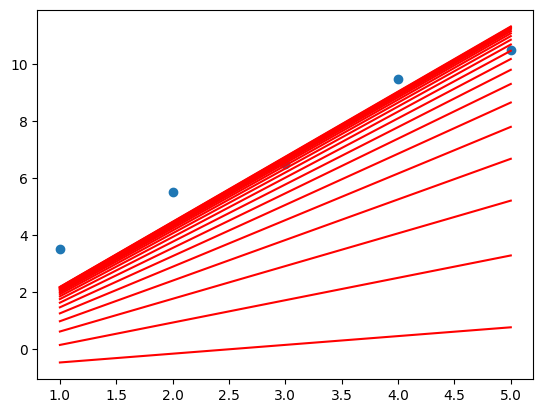

In [14]:
# Hyperparameters
learning_rate = 0.01
epochs = 20

# For plotting
losses = []
plt.scatter(x, y)
for epoch in range(20):
    # Forward pass
    y_pred = w * x + b

    # Compute loss (MSE)
    loss = torch.mean((y_pred - y) ** 2)
    # losses.append(loss.item())

    # Backward pass
    loss.backward()
    # Update weights manually (no optimizer for now)
    with torch.no_grad():
        w -= 0.01 * w.grad
        b -= 0.01 * b.grad

    # Zero the gradients
    w.grad.zero_()
    b.grad.zero_()

    # Detach tensors before plotting to avoid the error
    plt.plot(x.detach().numpy(), (w * x + b).detach().numpy(), color='red')


    # Logging
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}, w = {w.item():.4f}, b = {b.item():.4f}")

print(f"\nTrained model: y = {w.item():.2f}x + {b.item():.2f}")

Using tensorflow

In [15]:
import tensorflow as tf

In [16]:
# Data - convert to float tensors
x_tf = tf.constant([1, 2, 3, 4, 5], dtype=tf.float32)
y_tf = tf.constant([3.5, 5.5, 6.5, 9.5, 10.5], dtype=tf.float32)

In [17]:
# Initialize weights and bias (use tf.Variable to track gradients)
w_tf = tf.Variable(tf.random.normal([1]))
b_tf = tf.Variable(tf.random.normal([1]))

In [18]:
w_tf

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([0.80187064], dtype=float32)>

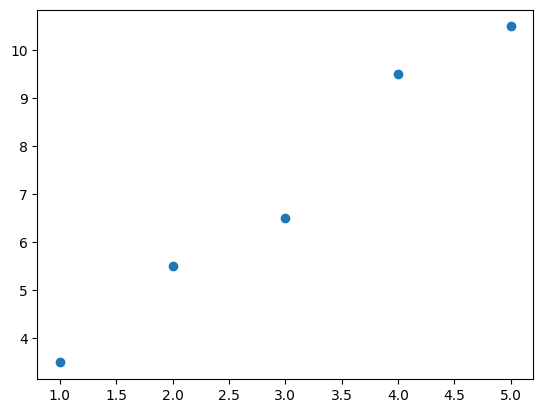

In [19]:
plt.scatter(x_tf, y_tf)

In [20]:
# Initialize weights and bias (use tf.Variable to track gradients)
w_tf = tf.Variable(tf.random.normal([1]))
b_tf = tf.Variable(tf.random.normal([1]))

Epoch 0: Loss = 14.6105, w = 1.4907, b = -0.2813

Trained model: y = 2.25x + 0.05


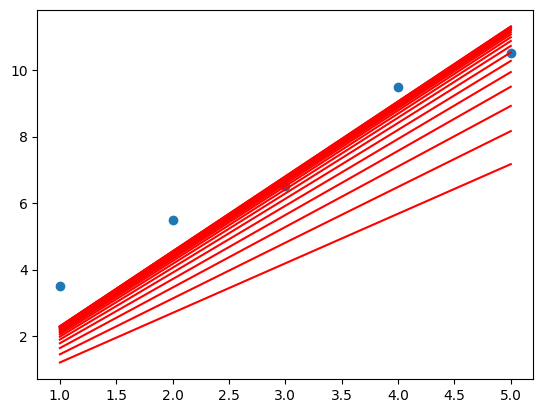

In [21]:
# Hyperparameters
lr = 0.01
epochs_tf = 20

# For plotting
plt.scatter(x_tf.numpy(), y_tf.numpy())

# Gradient Descent Loop
for epoch in range(epochs_tf):
    with tf.GradientTape() as tape:
        # Forward pass
        y_pred_tf = w_tf * x_tf + b_tf

        # Compute loss (MSE)
        loss_tf = tf.reduce_mean(tf.square(y_pred_tf - y_tf))

        # Calculate gradients
        gradients = tape.gradient(loss_tf, [w_tf, b_tf])

    # Update weights manually (using assign for in-place update)
    w_tf.assign_sub(lr * gradients[0])
    b_tf.assign_sub(lr * gradients[1])

    # Detach tensors before plotting to avoid the error
    plt.plot(x_tf.numpy(), (w_tf * x_tf + b_tf).numpy(), color='red')


    # Logging
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss_tf.numpy():.4f}, w = {w_tf.numpy()[0]:.4f}, b = {b_tf.numpy()[0]:.4f}")

print(f"\nTrained model: y = {w_tf.numpy()[0]:.2f}x + {b_tf.numpy()[0]:.2f}")

plt.show()